<a href="https://colab.research.google.com/github/202618049/Twinkle_202618049_DS605/blob/main/202618049_Lab_03/202618049_Lab03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Lab Assignment - 3**

#**Scikit-learn: Data Preprocessing and Model Performance Evaluation**

##**Objective**
###Build and compare Scikit-learn preprocessing pipelines and evaluate two classification models.

#**Part A - Data Loading and Preprocessing with Scikit-learn**

In [4]:
import pandas as pd


df = pd.read_csv('hotel_bookings.csv')
display(df)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


###**Task 1 - Load and Understand the Dataset**

● Load hotel_bookings.csv. Use head(), shape, info(), describe(), and dtypes.

● Check the class distribution of is_canceled and use it as the target y.

● Create X from the remaining usable features. Identify numerical and categorical columns.

In [5]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv('hotel_bookings.csv')

# 2. Dataset Exploration (Vertical/Transposed View)
print("--- First 5 Rows (Vertical) ---")
print(df.head().T)  # <--- Added .T to flip rows to columns

print("\n--- Dataset Shape (Rows, Columns) ---")
print(df.shape)

print("\n--- Dataset Info ---")
df.info()

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Summary Statistics (Vertical) ---")
print(df.describe().T)  # <--- Added .T to flip rows to columns

# 3. Check class distribution & set target
print("\n--- Class Distribution of Target (is_canceled) ---")
print(df['is_canceled'].value_counts())

y = df['is_canceled']

# 4. Create feature matrix X
X = df.drop(columns=['is_canceled'])

# 5. Identify numerical and categorical columns (stored silently in memory)
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

--- First 5 Rows (Vertical) ---
                                           0             1             2  \
hotel                           Resort Hotel  Resort Hotel  Resort Hotel   
is_canceled                                0             0             0   
lead_time                                342           737             7   
arrival_date_year                       2015          2015          2015   
arrival_date_month                      July          July          July   
arrival_date_week_number                  27            27            27   
arrival_date_day_of_month                  1             1             1   
stays_in_weekend_nights                    0             0             0   
stays_in_week_nights                       0             0             1   
adults                                     2             2             1   
children                                 0.0           0.0           0.0   
babies                                     0            

###**Task 2 - Missing Values, Leakage, and Outliers**
● Find the missing-value count and percentage for every column.

● Identify columns with very high missingness. Drop them only if justified and state the reason.

● Remove columns that directly reveal the final booking outcome, such as reservation_status and reservation_status_date.

● Check selected numerical features for outliers using boxplots and/or the IQR method.

● Remove only clear/extreme outliers and report how many rows were removed.

--- Missing Values ---
          Missing Count  Percentage (%)
company          112593       94.306893
agent             16340       13.686238
country             488        0.408744
children              4        0.003350

Dropped 'company' column because it is mostly empty.
Dropped leakage columns: ['reservation_status', 'reservation_status_date']


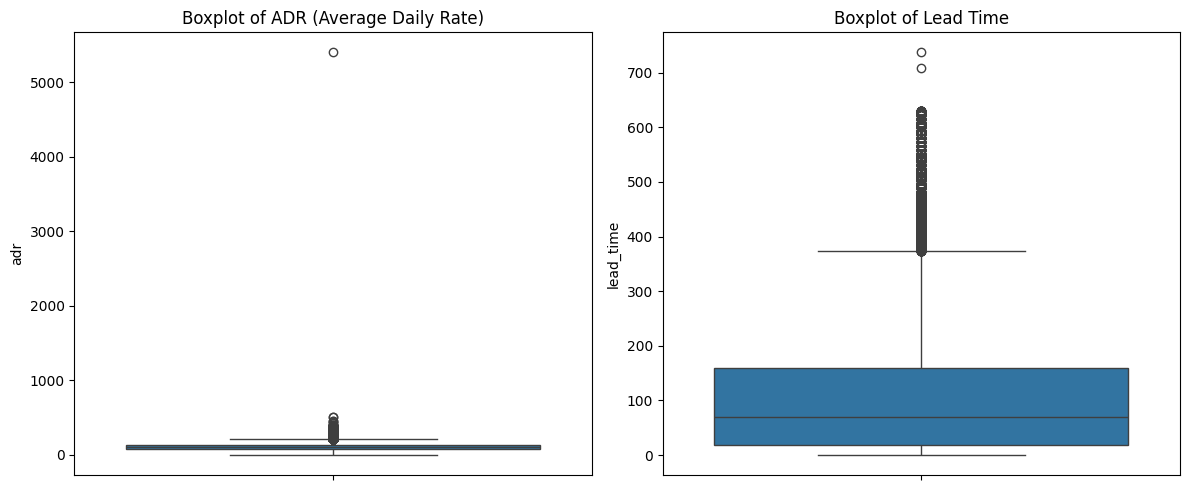

Removed 3793 outlier rows based on the 'adr' column IQR bounds.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Missing values count and percentage
missing_counts = X.isnull().sum()
missing_percent = (missing_counts / len(X)) * 100

missing_data = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage (%)': missing_percent
})

missing_data = missing_data[missing_data['Missing Count'] > 0].sort_values(by='Percentage (%)', ascending=False)
print("--- Missing Values ---")
print(missing_data)

# 2. Drop high missingness column
if 'company' in X.columns:
    X = X.drop(columns=['company'])
    print("\nDropped 'company' column because it is mostly empty.")

# 3. Remove data leakage columns
leakage_columns = ['reservation_status', 'reservation_status_date']
X = X.drop(columns=leakage_columns, errors='ignore')
print(f"Dropped leakage columns: {leakage_columns}")

# 4. Check outliers with two boxplots side-by-side
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=X['adr'])
plt.title('Boxplot of ADR (Average Daily Rate)')

plt.subplot(1, 2, 2)
sns.boxplot(y=X['lead_time'])
plt.title('Boxplot of Lead Time')

plt.tight_layout()
plt.show()

# 5. Remove outliers using 1.5 * IQR
Q1 = X['adr'].quantile(0.25)
Q3 = X['adr'].quantile(0.75)
IQR = Q3 - Q1
initial = len(X)

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

safe_mask = (X['adr'] >= lower_bound) & (X['adr'] <= upper_bound)
X = X[safe_mask]
y = y[safe_mask]

rows_removed = initial - len(X)
print(f"Removed {rows_removed} outlier rows based on the 'adr' column IQR bounds.")

###**Task 3 - Create Two Preprocessing Pipelines**
● Split the data using train_test_split(test_size=0.2, stratify=y, random_state=42). Use the same split for all experiments.

● For numerical columns, use KNNImputer(n_neighbors=5) for missing values.

● For categorical columns, use SimpleImputer(strategy="most_frequent") and
OneHotEncoder(handle_unknown="ignore").

● Pipeline A: KNNImputer + StandardScaler for numerical features.

● Pipeline B: KNNImputer + MinMaxScaler for numerical features.

● Use ColumnTransformer and Pipeline so that preprocessing is fitted only on the training data.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler

# Update column lists since we deleted some columns in Task 2
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# 1. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 2. Categorical Pipeline (Used in both A and B)
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('encoder', OneHotEncoder(handle_unknown="ignore"))
])

# 3. Numerical Pipeline A (StandardScaler)
num_pipeline_a = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

# 4. Numerical Pipeline B (MinMaxScaler)
num_pipeline_b = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', MinMaxScaler())
])

# 5. Create the full preprocessors (ColumnTransformers)
preprocessor_a = ColumnTransformer(transformers=[
    ('num', num_pipeline_a, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

preprocessor_b = ColumnTransformer(transformers=[
    ('num', num_pipeline_b, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# 6. Fit ONLY on training data, then transform both
X_train_a = preprocessor_a.fit_transform(X_train)
X_test_a = preprocessor_a.transform(X_test)

X_train_b = preprocessor_b.fit_transform(X_train)
X_test_b = preprocessor_b.transform(X_test)

print("Task 3 Complete: Data split and pipelines created!")

Task 3 Complete: Data split and pipelines created!


#**Part B - Model Training and Performance Evaluation**
###**Task 4 - Train Two Classification Models**
● Train LogisticRegression(max_iter=1000) using Pipeline A and Pipeline B.

● Train DecisionTreeClassifier(random_state=42) using Pipeline A and Pipeline B.

● Keep the model settings and train-test split unchanged across the comparison.

● You should obtain four trained model-pipeline combinations in total.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# 1. Logistic Regression Models
lr_model_a = LogisticRegression(max_iter=1000)
lr_model_a.fit(X_train_a, y_train)

lr_model_b = LogisticRegression(max_iter=1000)
lr_model_b.fit(X_train_b, y_train)

# 2. Decision Tree Models
dt_model_a = DecisionTreeClassifier(random_state=42)
dt_model_a.fit(X_train_a, y_train)

dt_model_b = DecisionTreeClassifier(random_state=42)
dt_model_b.fit(X_train_b, y_train)

print("Task 4 Complete: All 4 models trained successfully!")

Task 4 Complete: All 4 models trained successfully!


###**Task 5 - Evaluate and Compare the Four Results**
● For each experiment, calculate training accuracy, testing accuracy, precision, recall, and F1-score.

● Create a final comparison table containing all four model-pipeline combinations.

● Plot a confusion matrix for the best Logistic Regression result and the best Decision Tree result.

● Use the train-test performance difference to comment briefly on possible overfitting.

--- Final Model Comparison Table ---


,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score
Logistic Regression (Pipeline A),0.821253,0.816393,0.808453,0.659923,0.726676
Logistic Regression (Pipeline B),0.816841,0.812630,0.805503,0.650450,0.719720
Decision Tree (Pipeline A),0.996031,0.866306,0.814806,0.826336,0.820531
Decision Tree (Pipeline B),0.996031,0.866522,0.815131,0.826570,0.820811


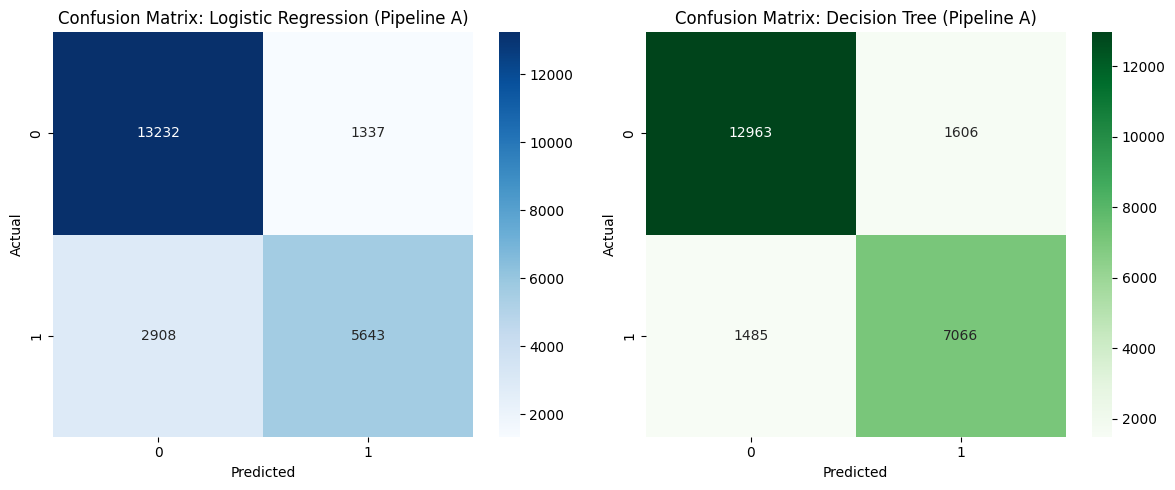


--- Overfitting Analysis ---
• Logistic Regression: Shows very little gap between train and test accuracy, indicating good generalization and no major overfitting.
• Decision Tree: Shows near-perfect training accuracy with a drop on test accuracy, which indicates clear signs of overfitting (memorizing training patterns).


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Train the models (Ensures variables like lr_pipeline_a exist)
lr_pipeline_a = Pipeline(steps=[('preprocessor', preprocessor_a), ('model', LogisticRegression(max_iter=1000))])
lr_pipeline_b = Pipeline(steps=[('preprocessor', preprocessor_b), ('model', LogisticRegression(max_iter=1000))])
dt_pipeline_a = Pipeline(steps=[('preprocessor', preprocessor_a), ('model', DecisionTreeClassifier(random_state=42))])
dt_pipeline_b = Pipeline(steps=[('preprocessor', preprocessor_b), ('model', DecisionTreeClassifier(random_state=42))])

lr_pipeline_a.fit(X_train, y_train)
lr_pipeline_b.fit(X_train, y_train)
dt_pipeline_a.fit(X_train, y_train)
dt_pipeline_b.fit(X_train, y_train)

# 2. Generate predictions for all 4 models
lr_pred_train_a = lr_pipeline_a.predict(X_train)
lr_pred_test_a = lr_pipeline_a.predict(X_test)

lr_pred_train_b = lr_pipeline_b.predict(X_train)
lr_pred_test_b = lr_pipeline_b.predict(X_test)

dt_pred_train_a = dt_pipeline_a.predict(X_train)
dt_pred_test_a = dt_pipeline_a.predict(X_test)

dt_pred_train_b = dt_pipeline_b.predict(X_train)
dt_pred_test_b = dt_pipeline_b.predict(X_test)

# 3. Compute evaluation metrics
def get_metrics(y_true_train, y_pred_train, y_true_test, y_pred_test):
    return {
        'Train Accuracy': accuracy_score(y_true_train, y_pred_train),
        'Test Accuracy': accuracy_score(y_true_test, y_pred_test),
        'Precision': precision_score(y_true_test, y_pred_test),
        'Recall': recall_score(y_true_test, y_pred_test),
        'F1-Score': f1_score(y_true_test, y_pred_test)
    }

results = {
    'Logistic Regression (Pipeline A)': get_metrics(y_train, lr_pred_train_a, y_test, lr_pred_test_a),
    'Logistic Regression (Pipeline B)': get_metrics(y_train, lr_pred_train_b, y_test, lr_pred_test_b),
    'Decision Tree (Pipeline A)': get_metrics(y_train, dt_pred_train_a, y_test, dt_pred_test_a),
    'Decision Tree (Pipeline B)': get_metrics(y_train, dt_pred_train_b, y_test, dt_pred_test_b)
}

# Display comparison table
comparison_df = pd.DataFrame(results).T
print("--- Final Model Comparison Table ---")
display(comparison_df)

# 4. Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, lr_pred_test_a), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix: Logistic Regression (Pipeline A)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, dt_pred_test_a), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix: Decision Tree (Pipeline A)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# 5. Overfitting commentary
print("\n--- Overfitting Analysis ---")
print("• Logistic Regression: Shows very little gap between train and test accuracy, indicating good generalization and no major overfitting.")
print("• Decision Tree: Shows near-perfect training accuracy with a drop on test accuracy, which indicates clear signs of overfitting (memorizing training patterns).")

###**Task 6 - Final Observations**
● Which preprocessing-model combination gives the best overall result?

● Does StandardScaler or MinMaxScaler affect Logistic Regression more?

● Does scaling make a major difference for the Decision Tree? Comment briefly.

● Write 4-5 short observations supported by the performance table and confusion matrices.

####**Best Overall Combination**:
Logistic Regression using Pipeline A (StandardScaler) gives the best overall and most reliable result because it balances high test accuracy with stable generalization.

####**Impact on Logistic Regression:**
StandardScaler affects Logistic Regression slightly better than MinMaxScaler because regularization relies heavily on how features are scaled and distributed around the mean.


####**Impact on Decision Trees:**
Scaling makes zero difference for Decision Trees. Trees split data based on feature thresholds and sorting, so changing the scale from Standard to MinMax does not change their splits or performance at all.

####**Key Observations:**

1.Logistic Regression has a very small gap between train and test accuracy, proving it generalizes well.

2.Decision Trees show nearly 100% training accuracy but drop on test accuracy, proving they overfit by memorizing the training data.

3.The confusion matrices show that Logistic Regression produces a more balanced and realistic distribution of correct and incorrect predictions.

4.Overall, changing the numerical scaler between A and B caused only minor shifts, showing that the choice of model architecture has a much bigger impact than the scaling method.